# 🌊 Wave Buoy Data from the U.S. National Data Buoy Center (NDBC)

> **Inputs:**
>
> **Outputs:**
> - Folder per buoy ID:
>   - `raw_data.csv`: downloaded data in the folder `inputs/buoy_data/buoy_ID`
>   - `buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
> `.pkl` files are used to validate CAWCR spectra satellite correction and BinWaves results
>
> **NOTE:** Directional spectra can be also downloaded from NDBC, although isn´t needed for the BinWaves


---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

---


> **For more information check the BlueMath Repo:** 
>
>  https://github.com/GeoOcean/BlueMath/blob/main/toolkit/data/NDBC_buoy_data.ipynb

In [1]:
from bluemath_tk.downloaders.noaa.noaa_downloader import NOAADownloader

noaa_downloader = NOAADownloader(base_path_to_download="inputs")
noaa_downloader

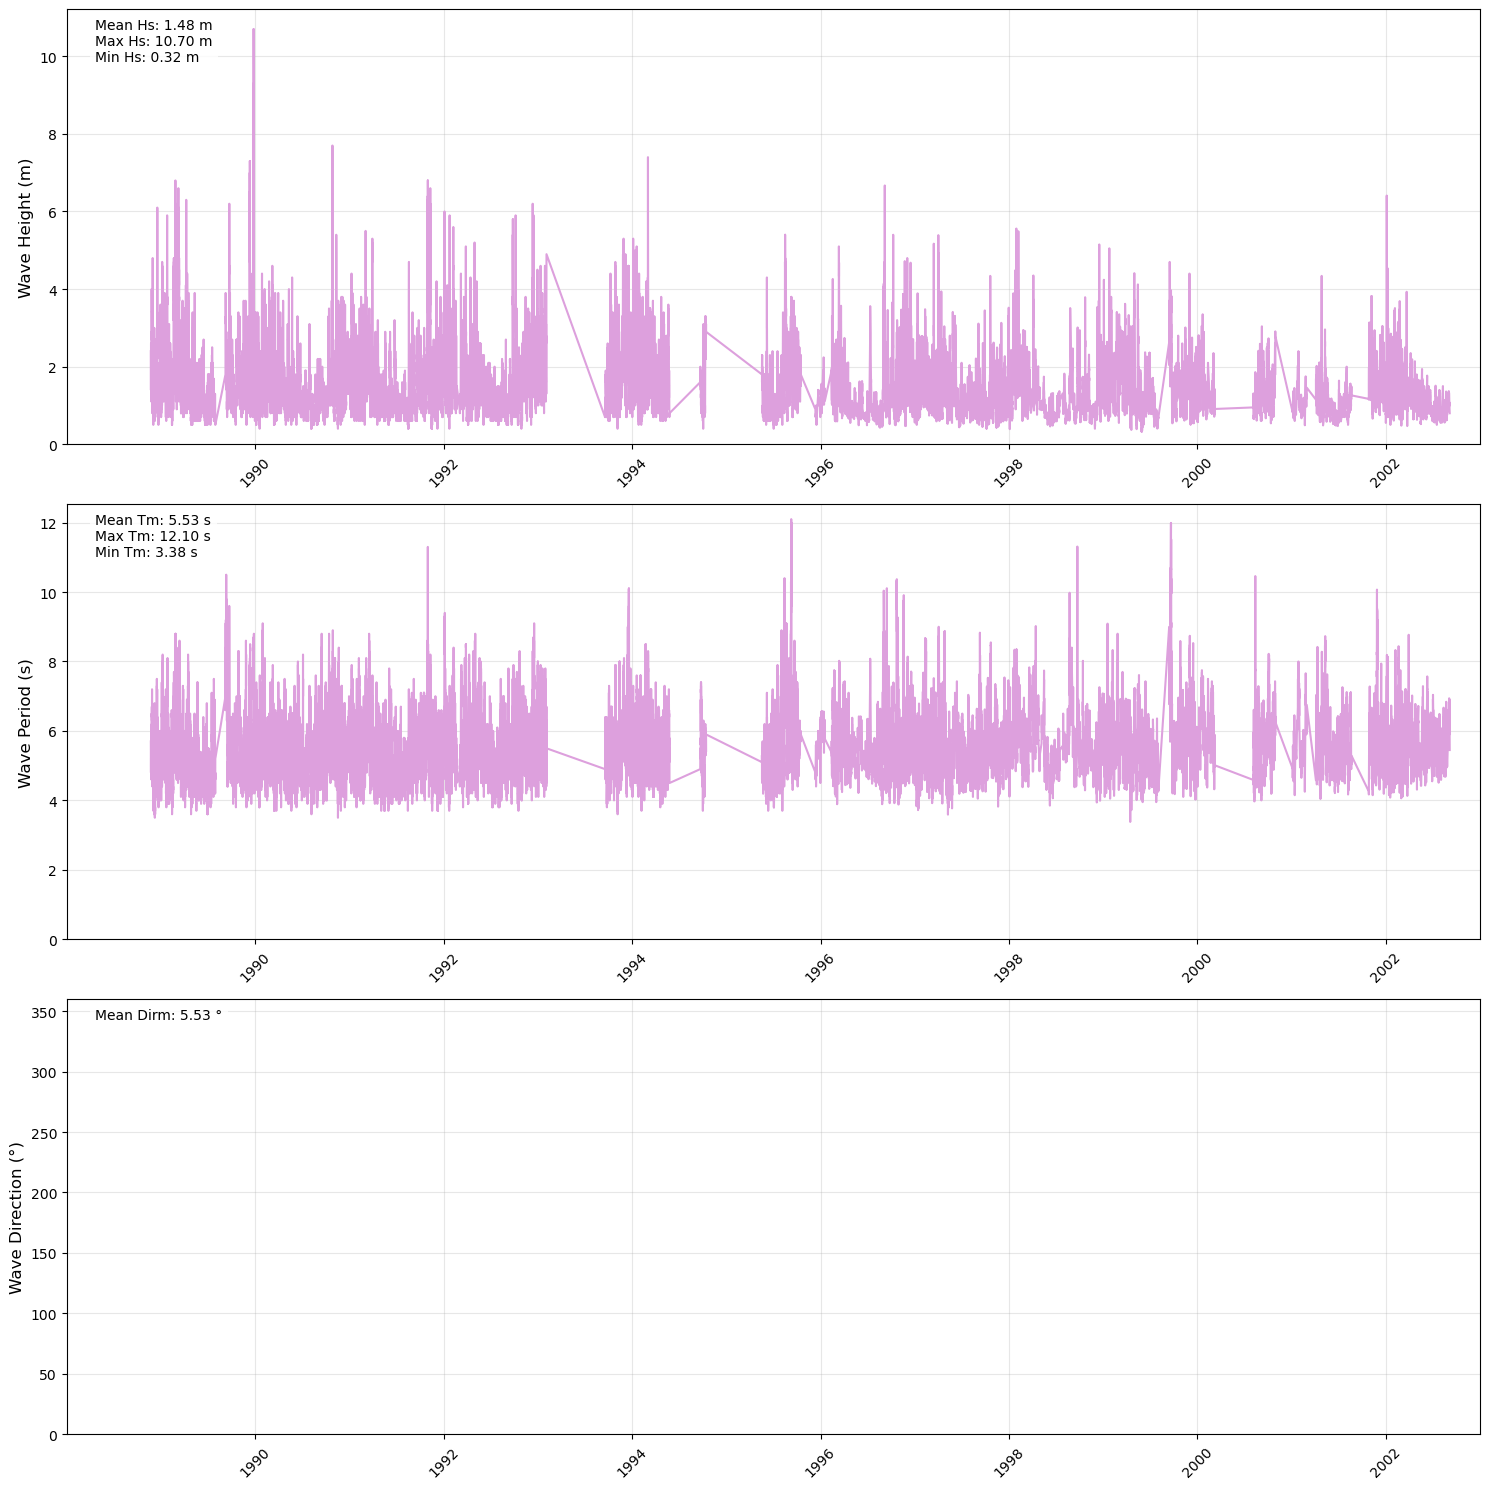

In [2]:
from utils.NDBC_utils import plot_bulk_timeseries
# buoy_ids = ['41013','41025','41108','41110','41120','41159','44056','44086','44088','44095','44100']
buoy_ids = ['dsln7']

for buoy_id in buoy_ids:
    buoy_df = noaa_downloader.download_data(
        data_type="bulk_parameters",
        load_df=True,
        buoy_id=buoy_id,
        years= list(range(1988,2003)) ,
    )
    _fig = plot_bulk_timeseries(buoy_df)

In [3]:
from utils.NDBC_utils import convert_buoy_csv_to_pkl

for buoy_id in buoy_ids:
    csv_path = f'inputs/buoy_data/{buoy_id}/buoy_{buoy_id}_bulk_parameters.csv'
    output_pkl_path = f'inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl'
    convert_buoy_csv_to_pkl(csv_path, output_pkl_path)

/vols/abedul/home/grupos/geocean/montanoj/ShoreShop2026/utils/NDBC_utils.py:91: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("1H").agg(



Successfully converted inputs/buoy_data/dsln7/buoy_dsln7_bulk_parameters.csv to inputs/buoy_data/buoy_dsln7_bulk_parameters.pkl
